Curtosis excess :15.15   (normal = 0)
Asimetría       :-0.32    (normal = 0)


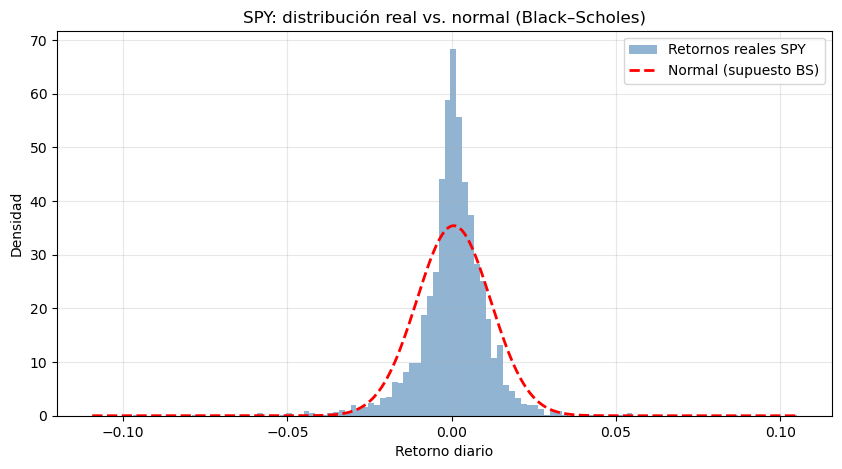

In [12]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

data     = yf.Ticker('SPY').history(period='10y')['Close']
retornos = data.pct_change().dropna()

print(f"Curtosis excess :{kurtosis(retornos):.2f}   (normal = 0)")
print(f"Asimetría       :{skew(retornos):.2f}    (normal = 0)")

x = np.linspace(retornos.min(), retornos.max(), 300)
plt.figure(figsize=(10, 5))
plt.hist(retornos, bins=120, density=True, alpha=0.6,
         color='steelblue', label='Retornos reales SPY')
plt.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
         'r--', linewidth=2, label='Normal (supuesto BS)')
plt.xlabel('Retorno diario')
plt.ylabel('Densidad')
plt.title('SPY: distribución real vs. normal (Black–Scholes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

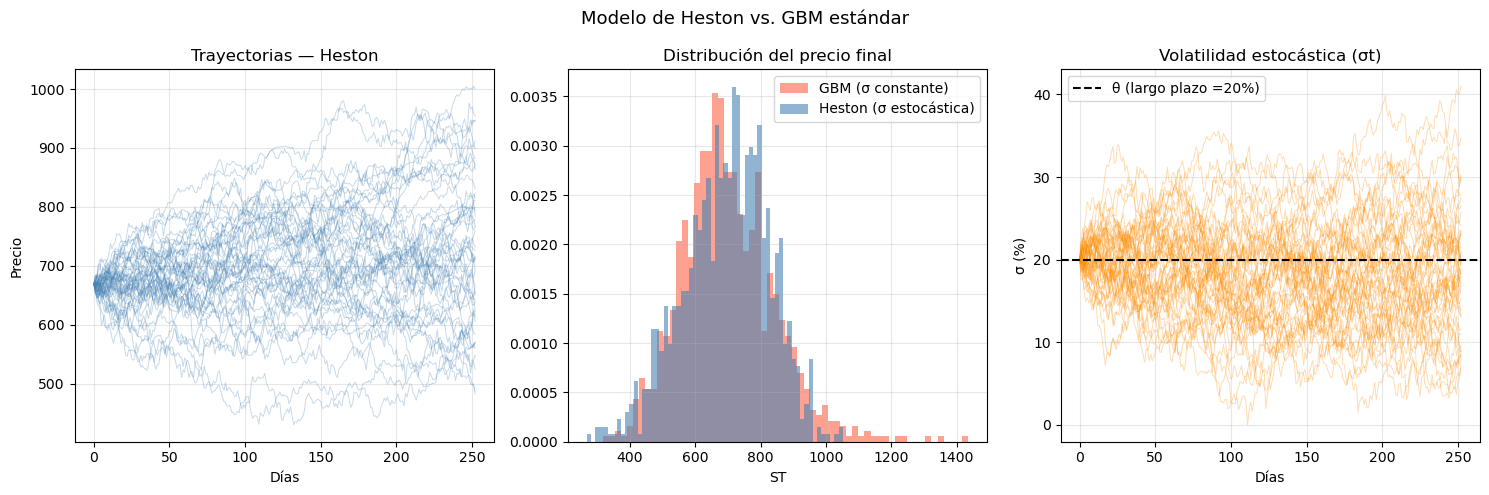

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# --- Comparación: GBM estándar vs. Heston ---
sigma_const = 0.20
dt = T / N
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trayectorias
for i in range(50):
    axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Distribución final: GBM vs Heston
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM (σ constante)')
axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Evolución de la varianza
for i in range(50):
    axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Modelo de Heston vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

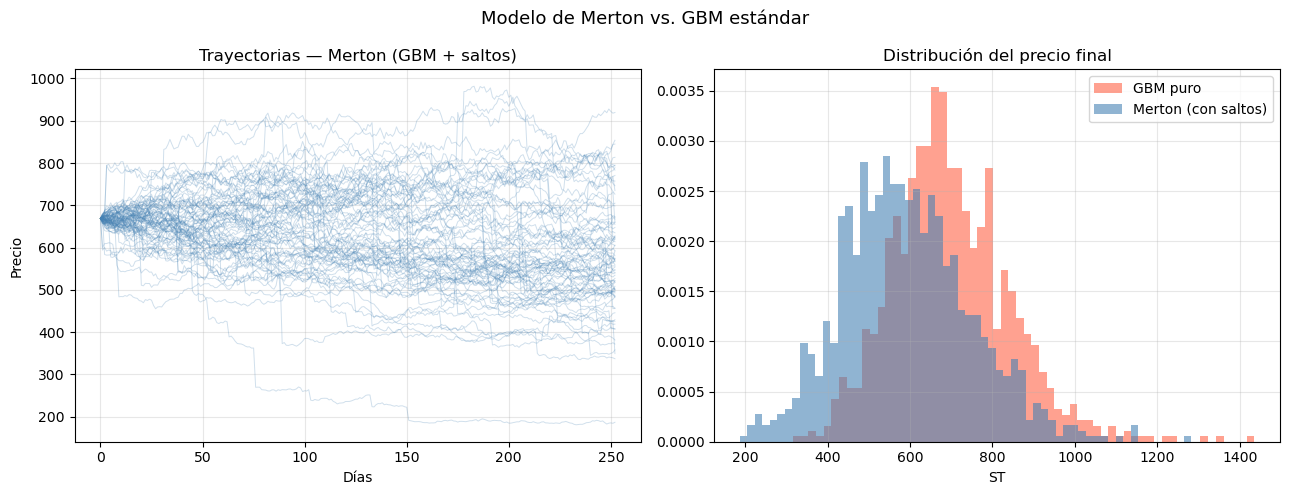

In [14]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = 4        # ~4 saltos por año
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias — algunos saltos visibles
for i in range(80):
    axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Comparación distribución final
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM puro')
axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo de Merton vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

### **Actividad**

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0
    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        v_pos = np.maximum(v[:, t-1], 0)
        v[:, t] = (v_pos + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)
        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * Zs)
    return S, v

def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0
    for t in range(1, N + 1):
        Z       = np.random.randn(M)
        gbm     = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        n_saltos = np.random.poisson(lam * dt, M)
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n)) if n > 0 else 0.0
            for n in n_saltos])
        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)
    return S

In [16]:
S0 = 669.03; mu = 0.042; T = 1.0; N = 252; M = 1000

# GBM estándar 
sigma_const = 0.20
np.random.seed(42)
dt = T / N
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1)); S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5*sigma_const**2)*dt + sigma_const*np.sqrt(dt)*Z[:, t-1])

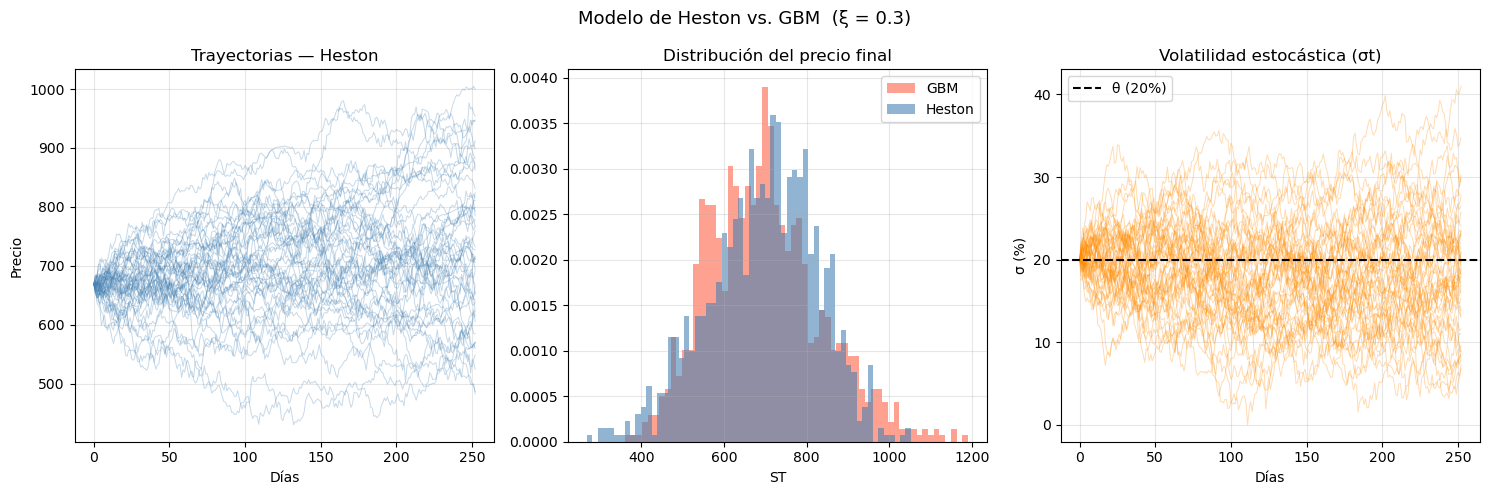

In [17]:
# PARTE 1 — HESTON: Simulación base 
S_h, v_h = simular_heston(S0, v0=0.04, mu=mu, kappa=2.0, theta=0.04,
                           xi=0.3, rho=-0.7, T=T, N=N, M=M)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(50):
    axes[0].plot(S_h[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston'); axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio'); axes[0].grid(True, alpha=0.3)
axes[1].hist(S_gbm[:,-1], bins=60, density=True, alpha=0.6, color='tomato', label='GBM')
axes[1].hist(S_h[:,-1],   bins=60, density=True, alpha=0.6, color='steelblue', label='Heston')
axes[1].set_title('Distribución del precio final'); axes[1].set_xlabel('ST')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
for i in range(50):
    axes[2].plot(np.sqrt(v_h[i])*100, alpha=0.3, linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(0.04)*100, color='black', linestyle='--', label='θ (20%)')
axes[2].set_title('Volatilidad estocástica (σt)'); axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('Modelo de Heston vs. GBM  (ξ = 0.3)', fontsize=13)
plt.tight_layout(); plt.show()

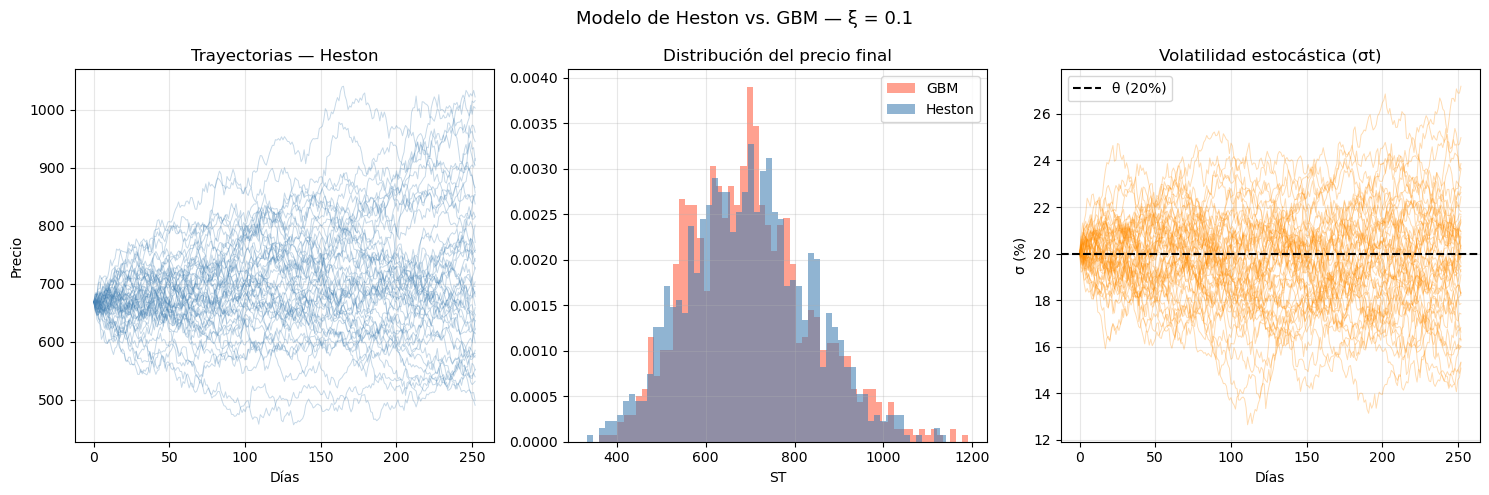

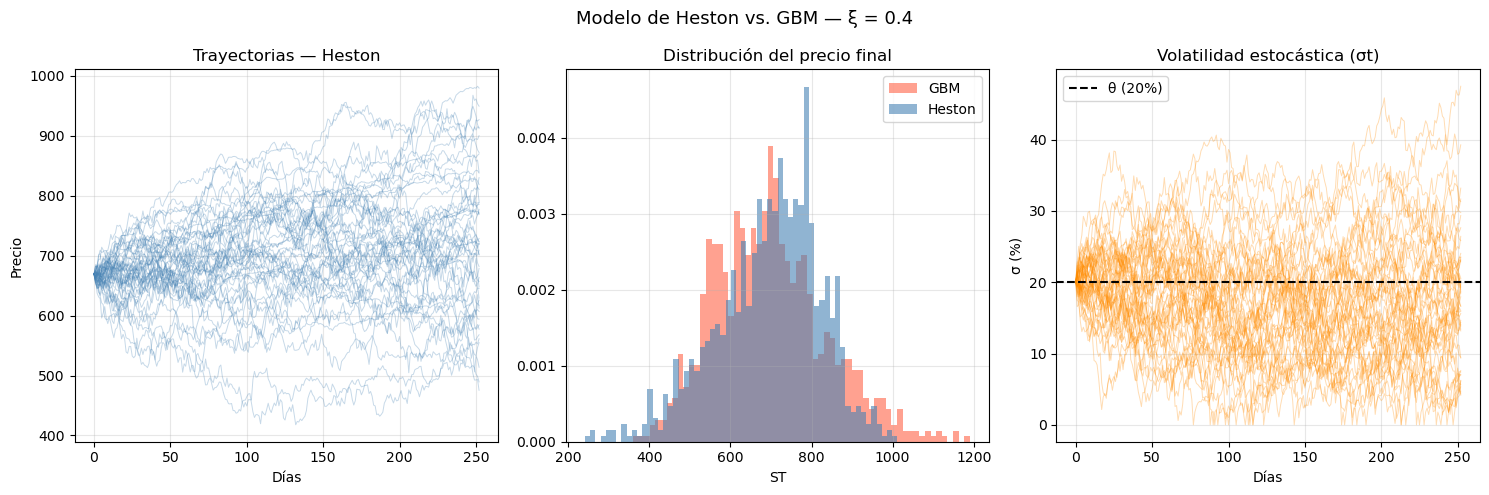

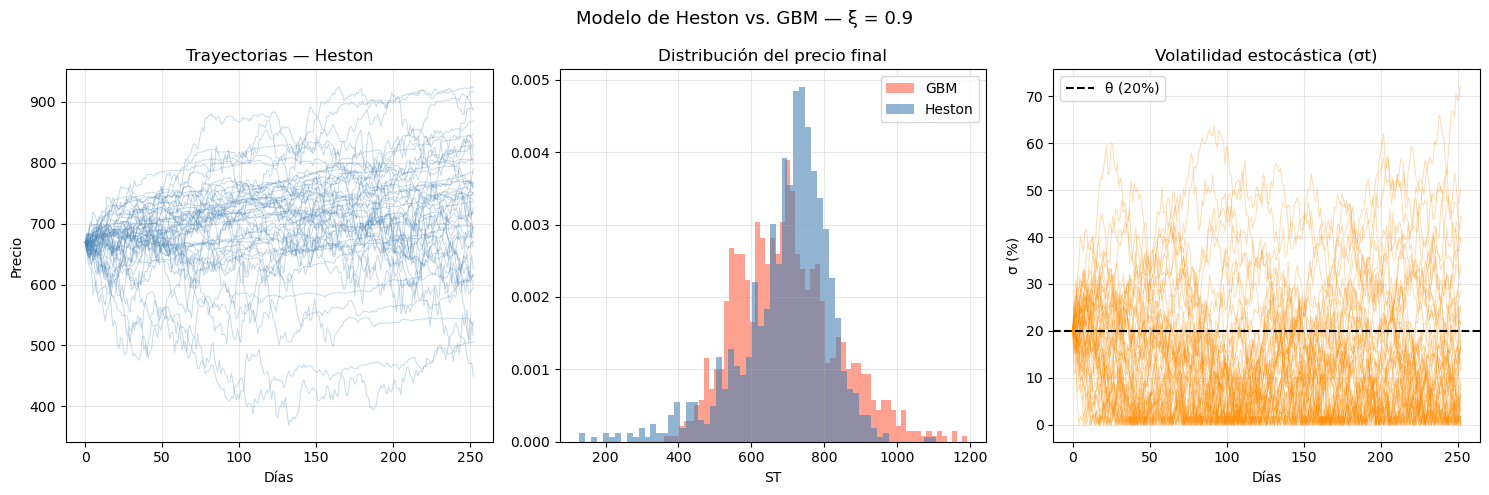

In [18]:
# PARTE 2 — HESTON: Variación de ξ (vol of vol)

for xi_val in [0.1, 0.4, 0.9]:
    S_h, v_h = simular_heston(S0, v0=0.04, mu=mu, kappa=2.0, theta=0.04,
                               xi=xi_val, rho=-0.7, T=T, N=N, M=M)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i in range(50):
        axes[0].plot(S_h[i], alpha=0.3, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Heston'); axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Precio'); axes[0].grid(True, alpha=0.3)
    axes[1].hist(S_gbm[:,-1], bins=60, density=True, alpha=0.6, color='tomato', label='GBM')
    axes[1].hist(S_h[:,-1],   bins=60, density=True, alpha=0.6, color='steelblue', label='Heston')
    axes[1].set_title('Distribución del precio final'); axes[1].set_xlabel('ST')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    for i in range(50):
        axes[2].plot(np.sqrt(v_h[i])*100, alpha=0.3, linewidth=0.7, color='darkorange')
    axes[2].axhline(np.sqrt(0.04)*100, color='black', linestyle='--', label='θ (20%)')
    axes[2].set_title('Volatilidad estocástica (σt)'); axes[2].set_xlabel('Días')
    axes[2].set_ylabel('σ (%)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    plt.suptitle(f'Modelo de Heston vs. GBM — ξ = {xi_val}', fontsize=13)
    plt.tight_layout(); plt.show()

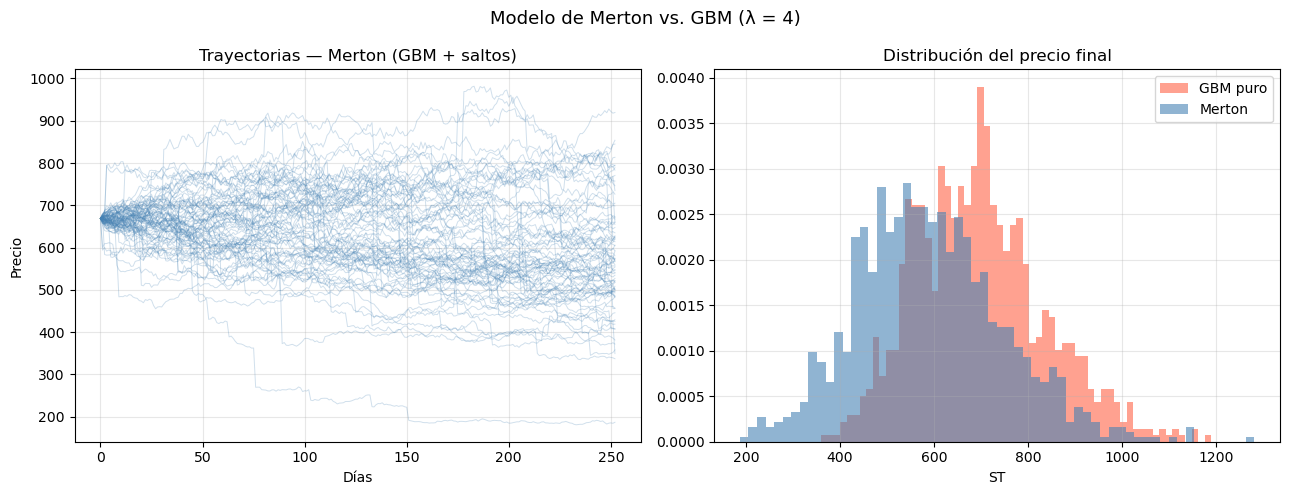

In [19]:
# PARTE 3 — MERTON

S_m = simular_merton(S0, mu=mu, sigma=0.15, lam=4,
                     mu_j=-0.05, sigma_j=0.10, T=T, N=N, M=M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i in range(80):
    axes[0].plot(S_m[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días'); axes[0].set_ylabel('Precio'); axes[0].grid(True, alpha=0.3)
axes[1].hist(S_gbm[:,-1], bins=60, density=True, alpha=0.6, color='tomato', label='GBM puro')
axes[1].hist(S_m[:,-1],   bins=60, density=True, alpha=0.6, color='steelblue', label='Merton')
axes[1].set_title('Distribución del precio final'); axes[1].set_xlabel('ST')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Modelo de Merton vs. GBM (λ = 4)', fontsize=13)
plt.tight_layout(); plt.show()

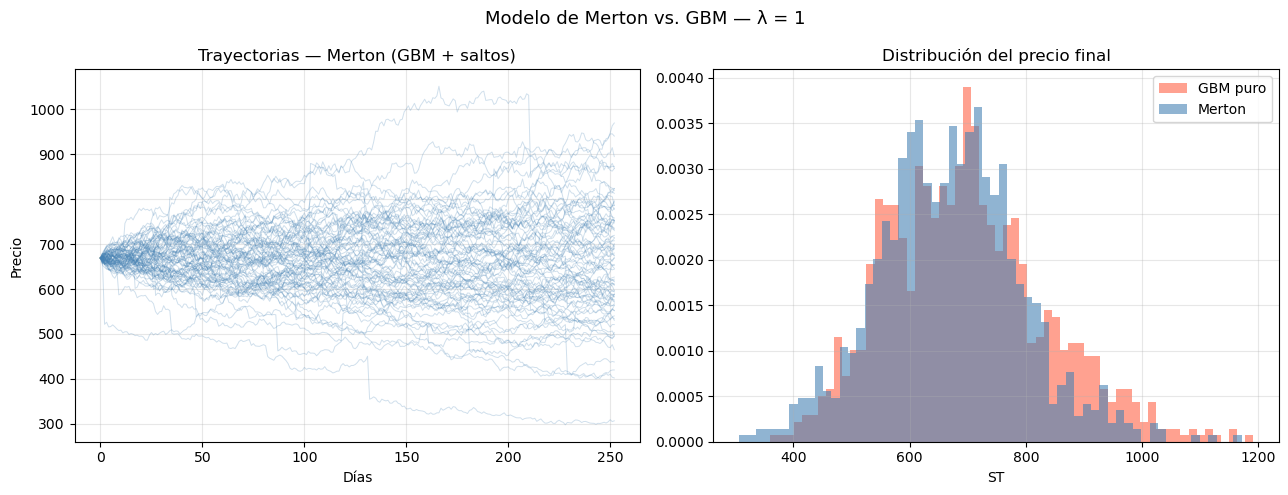

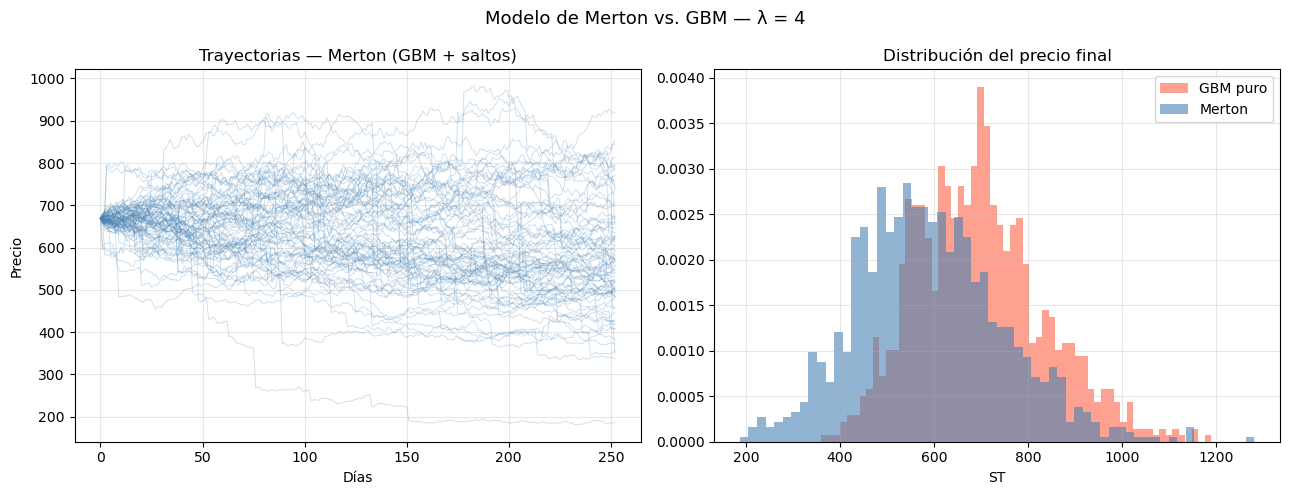

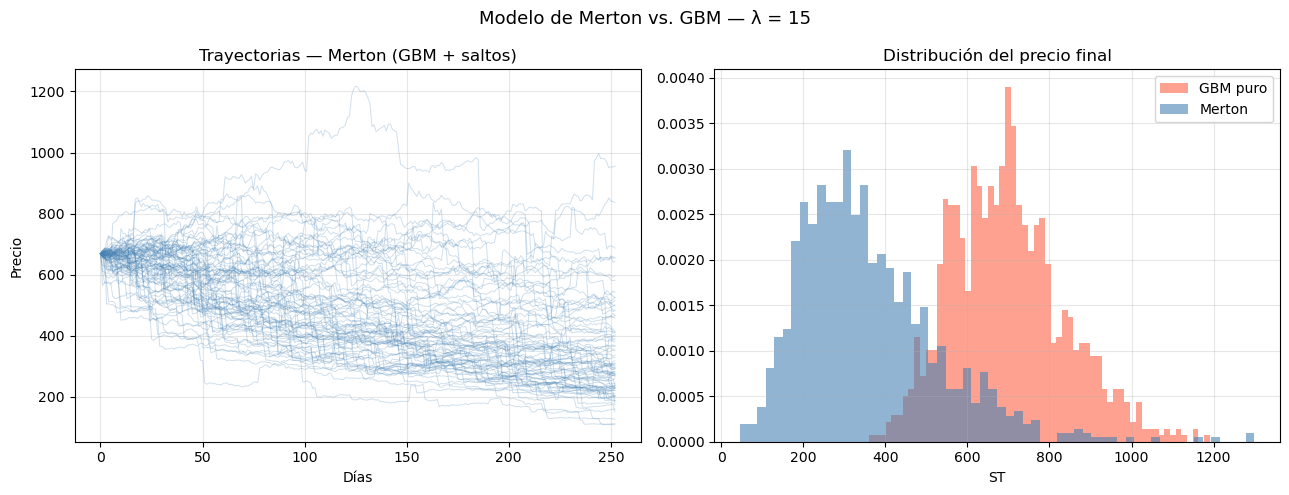

In [20]:
# PARTE 4 — MERTON: Variación de λ (intensidad de saltos)

for lam_val in [1, 4, 15]:
    S_m = simular_merton(S0, mu=mu, sigma=0.15, lam=lam_val,
                         mu_j=-0.05, sigma_j=0.10, T=T, N=N, M=M)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for i in range(80):
        axes[0].plot(S_m[i], alpha=0.25, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
    axes[0].set_xlabel('Días'); axes[0].set_ylabel('Precio'); axes[0].grid(True, alpha=0.3)
    axes[1].hist(S_gbm[:,-1], bins=60, density=True, alpha=0.6, color='tomato', label='GBM puro')
    axes[1].hist(S_m[:,-1],   bins=60, density=True, alpha=0.6, color='steelblue', label='Merton')
    axes[1].set_title('Distribución del precio final'); axes[1].set_xlabel('ST')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'Modelo de Merton vs. GBM — λ = {lam_val}', fontsize=13)
    plt.tight_layout(); plt.show()

- **En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?**

Sobre la distribución del precio final: Con ξ = 0.1 la distribución del precio final es bastante similar al GBM, ambas están concentradas alrededor de 600–800 y tienen una forma parecida. Conforme ξ aumenta a 0.4 y especialmente a 0.9, la distribución de Heston se ensancha, aparecen más observaciones en los extremos, colas más gruesas, y el pico se vuelve menos pronunciado. Esto se debe a que una mayor vol of vol hace que la volatilidad misma fluctúe mucho más, generando períodos de calma y períodos de estrés extremo. 

Sobre el skew: Con ξ = 0.1, el histograma de Heston luce casi simétrico y muy parecido al GBM. A medida que ξ crece, la distribución adquiere mayor asimetría negativa (skew negativo): la cola izquierda se extiende más, lo que se aprecia en que aparecen precios finales más bajos que el GBM no genera. Esto tiene sentido porque ξ alto, combinado con ρ = −0.7, provoca que caídas de precio vayan acompañadas de aumentos de volatilidad, amplificando los movimientos a la baja.

- **En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?**

Trayectorias: Con λ = 1 las trayectorias son relativamente suaves, con saltos esporádicos pero poco frecuentes; el abanico de precios finales se parece al GBM. Con λ = 4 ya se ven caídas abruptas más frecuentes y algunas trayectorias se alejan marcadamente hacia abajo. Con λ = 15 el efecto es drástico: prácticamente todas las trayectorias muestran saltos continuos hacia abajo, y muchas terminan en precios por debajo de 400 o incluso cerca de 200, lo que evidencia que la componente de saltos negativos domina por completo al drift positivo.

Distribución final: La diferencia con el GBM se vuelve cada vez más severa. Con λ = 1 las distribuciones aún se solapan considerablemente. Con λ = 4 la distribución de Merton ya se desplaza claramente a la izquierda respecto al GBM. Con λ = 15 la separación es total: la distribución de Merton está completamente desplazada hacia precios bajos, mientras el GBM se mantiene centrado en 600–800. Esto confirma que λ alto con saltos negativos produce una deriva negativa acumulada que BS no puede capturar.

- **Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?**

Si el mercado real tiene colas más gruesas, especialmente a la izquierda, como se ve en las distribuciones de Heston y Merton, el put muy OTM tiene en realidad más probabilidad de terminar ITM de lo que BS supone. BS, al asumir una distribución normal con colas delgadas, subestima esa probabilidad de caída extrema. Por lo tanto, el precio BS de un put muy OTM estará subestimado respecto al precio real de mercado. BS subestima el put OTM porque ignora exactamente los eventos que más le importan a ese instrumento, los saltos bruscos hacia abajo y las colas gruesas a la izquierda.

- **Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?**

En la práctica esto es una simplificación importante porque los saltos en los mercados reales no ocurren de forma homogénea, tienden a agruparse en períodos de crisis o alta incertidumbre. Por ejemplo, durante una crisis financiera los saltos negativos se vuelven mucho más frecuentes que en períodos de calma. Un λ constante no puede capturar este comportamiento: subestima el riesgo en períodos de estrés y lo sobreestima en períodos tranquilos.

- **¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?**

A pesar de que Heston y Merton son más precisos en describir la dinámica real de los precios, BS sigue dominando en la práctica por varias razones. BS tiene solución analítica cerrada, lo que permite calcular precios y griegas en microsegundos. Heston y Merton requieren integración numérica o simulación, lo que es costoso computacionalmente cuando se necesita re-calcular miles de opciones en tiempo real. También el mercado usa la volatilidad implícita de BS como unidad de cotización, no como creencia literal en la distribución normal, sino como un código compartido. Todos los participantes hablan BS y ajustan la volatilidad implícita para incorporar las colas gruesas. Es un lenguaje conveniente aunque imperfecto. Por ultimo, Heston y Merton tienen más parámetros que son difíciles de estimar de forma estable y consistente. BS solo requiere una volatilidad, lo que lo hace robusto en la práctica.
